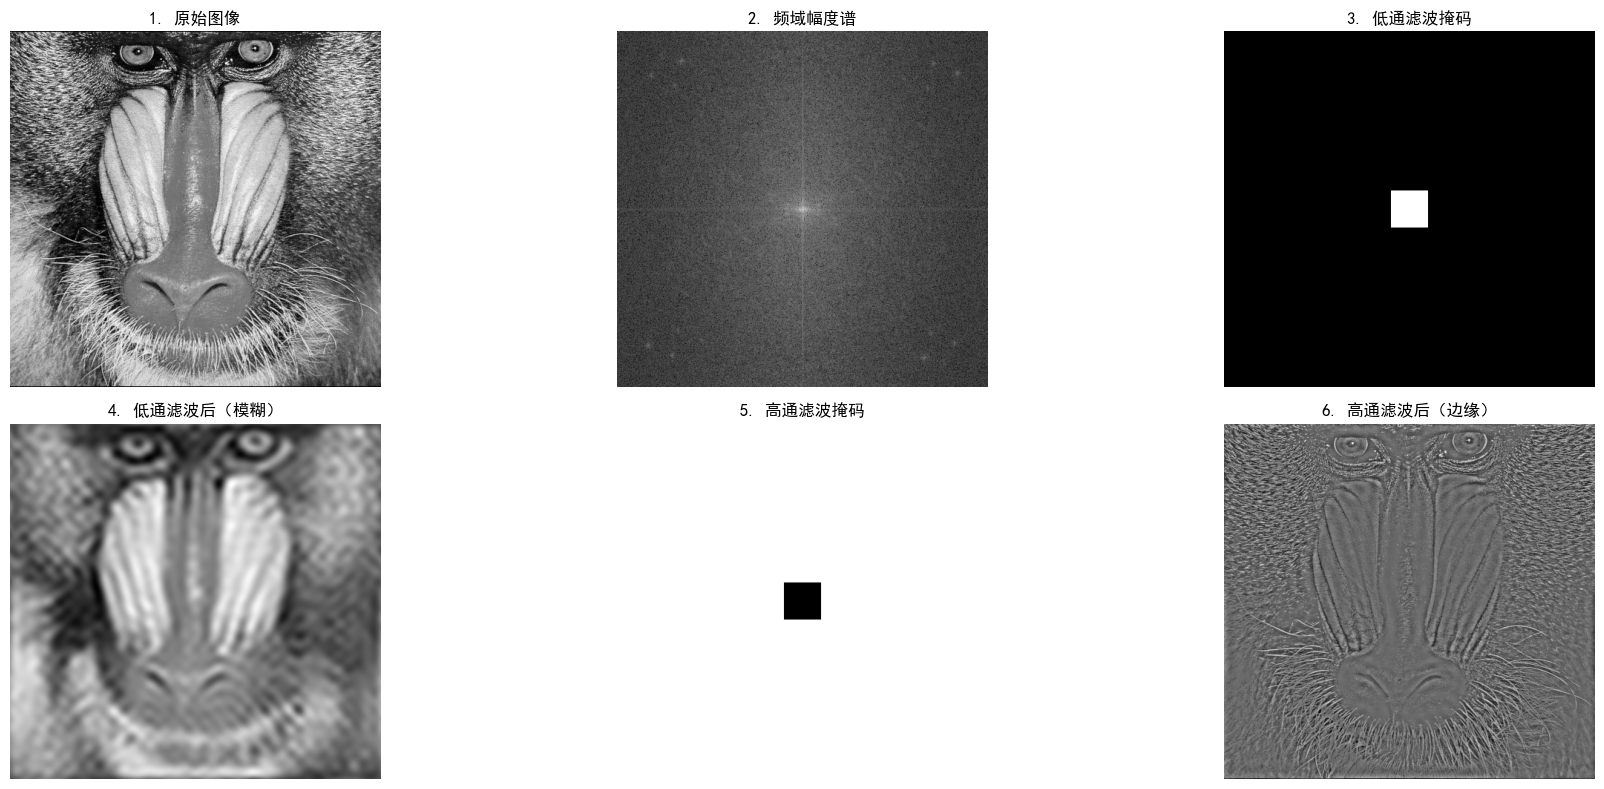

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取并预处理图像
img_path = "baboon.bmp"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("图片读取失败，请检查路径/文件！")
img = img / 255.0  # 归一化到0-1

# 2. 二维FFT + 频谱中心化
fft2_result = np.fft.fft2(img)         # 二维快速傅里叶变换
fft2_shift = np.fft.fftshift(fft2_result)  # 频谱中心化

# 3. 构建频域滤波器
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2  # 频域中心

# 3.1 低通滤波器（保留低频，模糊图像）
low_pass_mask = np.zeros((rows, cols), np.float32)
low_pass_mask[crow-25:crow+25, ccol-25:ccol+25] = 1  # 中心50x50区域保留

# 3.2 高通滤波器（保留高频，提取边缘）
high_pass_mask = np.ones((rows, cols), np.float32)
high_pass_mask[crow-25:crow+25, ccol-25:ccol+25] = 0  # 中心50x50区域屏蔽

# 4. 频域滤波 + 逆变换
# 低通滤波
fft2_low = fft2_shift * low_pass_mask
ifft2_low = np.fft.ifft2(np.fft.ifftshift(fft2_low))
img_low = np.real(ifft2_low)

# 高通滤波
fft2_high = fft2_shift * high_pass_mask
ifft2_high = np.fft.ifft2(np.fft.ifftshift(fft2_high))
img_high = np.real(ifft2_high)

# 5. 可视化对比
plt.figure(figsize=(20, 8))

# 原始图像
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('1. 原始图像', fontsize=12)
plt.axis('off')

# 频域幅度谱
plt.subplot(2, 3, 2)
amplitude_log = np.log(1 + np.abs(fft2_shift))
plt.imshow(amplitude_log, cmap='gray')
plt.title('2. 频域幅度谱', fontsize=12)
plt.axis('off')

# 低通滤波掩码
plt.subplot(2, 3, 3)
plt.imshow(low_pass_mask, cmap='gray')
plt.title('3. 低通滤波掩码', fontsize=12)
plt.axis('off')

# 低通滤波结果
plt.subplot(2, 3, 4)
plt.imshow(img_low, cmap='gray')
plt.title('4. 低通滤波后（模糊）', fontsize=12)
plt.axis('off')

# 高通滤波掩码
plt.subplot(2, 3, 5)
plt.imshow(high_pass_mask, cmap='gray')
plt.title('5. 高通滤波掩码', fontsize=12)
plt.axis('off')

# 高通滤波结果
plt.subplot(2, 3, 6)
plt.imshow(img_high, cmap='gray')
plt.title('6. 高通滤波后（边缘）', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()